In [2]:
pip install numpy pandas matplotlib tensorflow scikit-learn

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [6]:
data = pd.read_excel('predict_energy_consumption.xlsx')
data.head()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
0,24.363503,31.107976,5.234114,705.432695,307.398145
1,38.767858,52.514057,4.939576,817.013258,412.444548
2,33.299849,72.376750,18.125092,325.421109,392.072418
3,29.966462,63.933493,4.990924,662.386690,119.254957
4,18.900466,68.393669,5.438995,614.571385,117.162261


In [8]:
data.tail()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
995,17.289552,59.417309,17.305915,497.896331,453.828793
996,37.932839,77.396877,3.145464,400.961061,103.721455
997,18.420466,24.137481,6.195757,455.115084,197.529277
998,38.755934,23.423283,5.800911,576.946528,417.085421
999,26.150144,36.931224,17.428281,245.230623,318.790570


In [10]:
data.describe()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,27.256414,50.421038,10.048115,541.337543,272.347395
std,7.303434,17.531394,5.813484,257.840410,129.064474
min,15.115801,20.193096,0.000233,100.588052,50.013823
25%,20.899332,34.464456,5.227020,317.710693,160.238303
50%,27.420184,51.124034,10.012278,535.851355,272.569144
75%,33.607990,65.627903,15.182071,763.786729,382.997053
max,39.992942,79.964824,19.956417,999.601933,498.987225


In [12]:
data.describe(include='all')

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,27.256414,50.421038,10.048115,541.337543,272.347395
std,7.303434,17.531394,5.813484,257.840410,129.064474
min,15.115801,20.193096,0.000233,100.588052,50.013823
25%,20.899332,34.464456,5.227020,317.710693,160.238303
50%,27.420184,51.124034,10.012278,535.851355,272.569144
75%,33.607990,65.627903,15.182071,763.786729,382.997053
max,39.992942,79.964824,19.956417,999.601933,498.987225


In [14]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,1000.0,27.256414,7.303434,15.115801,20.899332,27.420184,33.607990,39.992942
humidity,1000.0,50.421038,17.531394,20.193096,34.464456,51.124034,65.627903,79.964824
wind_speed,1000.0,10.048115,5.813484,0.000233,5.227020,10.012278,15.182071,19.956417
solar_irradiance,1000.0,541.337543,257.840410,100.588052,317.710693,535.851355,763.786729,999.601933
energy_consumption,1000.0,272.347395,129.064474,50.013823,160.238303,272.569144,382.997053,498.987225


In [16]:
data.shape

(1000, 5)

In [18]:
x= data[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']].values
y= data['energy_consumption'].values

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
scaler= StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [28]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

In [30]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

In [32]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [34]:
history = model.fit(x_train,y_train,epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 88465.8906 - mae: 267.7943 - val_loss: 83432.3125 - val_mae: 258.5020
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 87645.6250 - mae: 267.8113 - val_loss: 82749.9141 - val_mae: 257.1761
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 86871.1016 - mae: 266.8571 - val_loss: 81699.8047 - val_mae: 255.1250
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 83556.7734 - mae: 258.4324 - val_loss: 80152.6406 - val_mae: 252.0625
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 94019.7969 - mae: 279.3956 - val_loss: 77872.4609 - val_mae: 247.4764
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 83530.0781 - mae: 260.3368 - val_loss: 74746.5156 - val_mae: 241.0355
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 80127.5703 - mae: 252.8642 - val_loss: 70610.2266 - val_mae: 232.2186
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 74607.5938 - mae: 239.6575 - val_loss:

In [36]:
test_loss, test_mae = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Mean Absolute Error: {test_mae:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 17908.7969 - mae: 114.8590 
Test Mean Absolute Error: 115.23


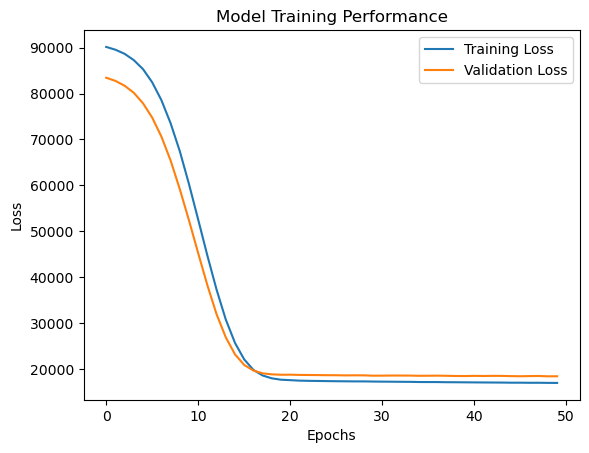

In [38]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Training Performance')
plt.legend()
plt.show()

In [40]:
pridictions = model.predict(x_test)
pridictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[290.7266 ],
       [244.4955 ],
       [251.10667],
       [209.17043],
       [347.76526],
       [324.74115],
       [297.49356],
       [283.5163 ],
       [290.4347 ],
       [279.27747],
       [238.61084],
       [269.0128 ],
       [272.33606],
       [240.34058],
       [302.56097],
       [314.1963 ],
       [262.25818],
       [313.7881 ],
       [301.96933],
       [247.94702],
       [274.52203],
       [280.31976],
       [282.3056 ],
       [278.18585],
       [257.51117],
       [249.88527],
       [258.29446],
       [310.85934],
       [315.03644],
       [267.4751 ],
       [240.66884],
       [314.37158],
       [304.07144],
       [269.97592],
       [314.76526],
       [292.53967],
       [215.14345],
       [260.85474],
       [289.9834 ],
       [242.35014],
       [244.22633],
       [246.02812],
       [250.17117],
       [253.17317],
       [269.4265 ],
       [256.79474],
       [258.78656],
       [260.75305],
       [290.46747],
       [281.7567 ],


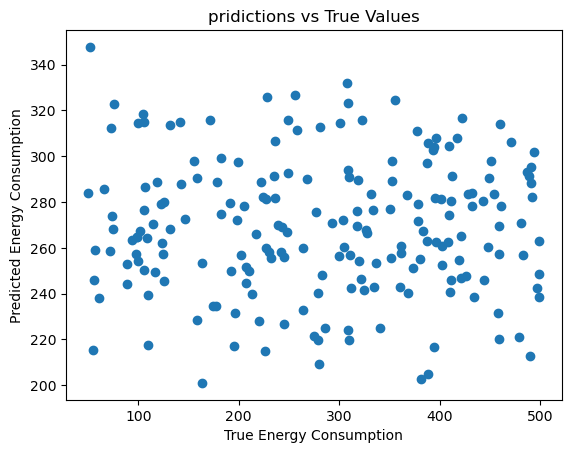

In [42]:
plt.scatter(y_test, pridictions)
plt.xlabel('True Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('pridictions vs True Values')
plt.show()